In [1]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline


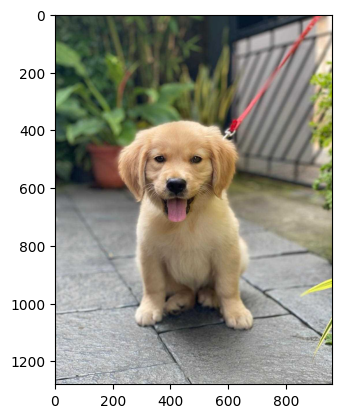

In [2]:
full = cv2.imread('images/puppy.jpg')
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)
plt.imshow(full)

In [3]:
full.shape

(1280, 960, 3)

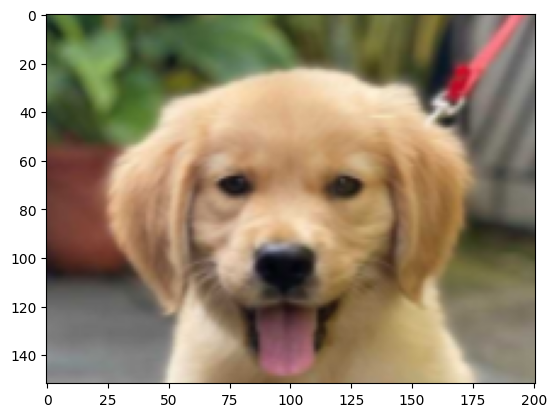

In [5]:
face = cv2.imread('images/puppyFace.jpg')
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
plt.imshow(face)

In [6]:
face.shape

(152, 201, 3)

In [7]:
# eval function example
# eval funvtion is used to evaluate a string as a python expression and return the result.
sum([1,2,3])

6

In [8]:
mystring = 'sum'
eval (mystring)

<function sum(iterable, /, start=0)>

In [9]:
#myfunc = eval (mystring) 
# or
myfunc = eval ('sum')
myfunc([1,2,3])

6

In [10]:
# All the 6 method comparison in a list
# note how we are using the string , later on we will use eval() to convert to function 
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

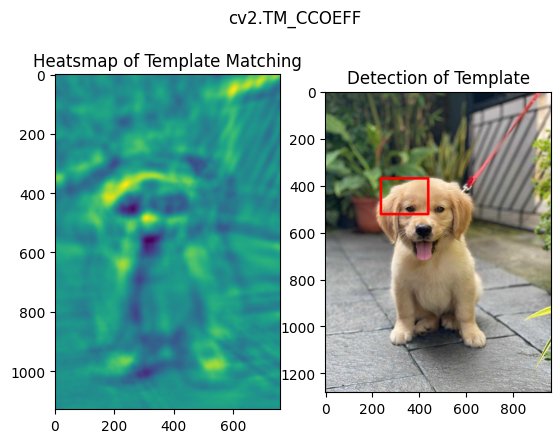

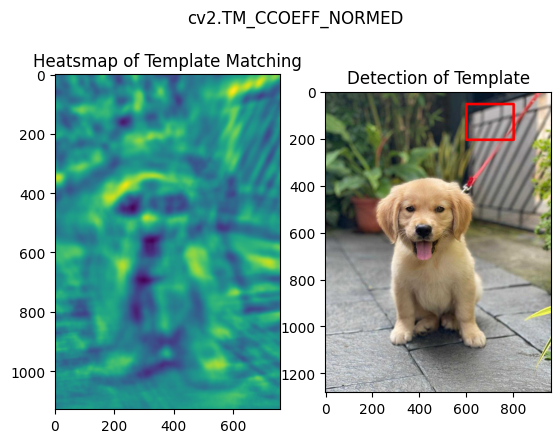

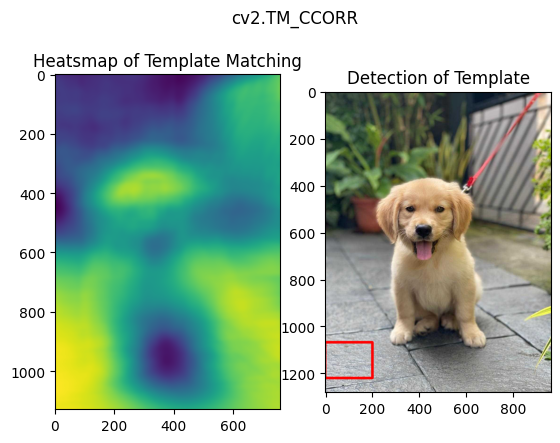

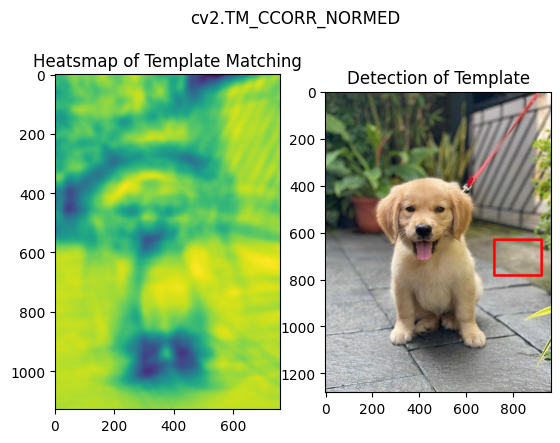

In [13]:
for m in methods:

# create a copy of the full image to draw the rectangle on
    full_copy = full.copy()
    method = eval(m)

# Template matching
    res = cv2.matchTemplate(full_copy, face, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc      
        height, width, channels = face.shape
        bottom_right = (top_left[0] + width, top_left[1] + height)
        cv2.rectangle(full_copy, top_left, bottom_right, (255,0,0), 10)
    
        # PLOT AND SHOW THE IMAGE
        plt.subplot(121)
        plt.imshow(res)
        plt.title('Heatsmap of Template Matching')

        plt.subplot(122)
        plt.imshow(full_copy)
        plt.title('Detection of Template')

        # title with the method used
        plt.suptitle(m)
        plt.show()
        print('\n')
        print('\n')

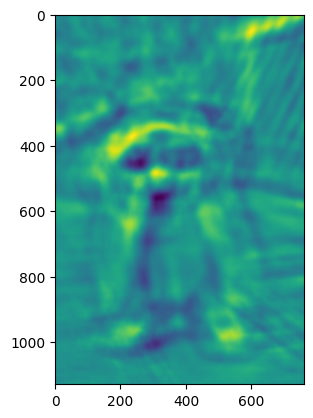

In [12]:
# print(res) 
my_method = eval('cv2.TM_CCOEFF')
res = cv2.matchTemplate(full, face, my_method)
plt.imshow(res)